# Convolutional Neural Network (CNN) Architectures: A Comprehensive Comparison

This notebook provides a detailed explanation and comparison of the most influential CNN architectures in the history of deep learning. We cover their design philosophy, key innovations, layer structures, parameter counts, and performance characteristics.

---

## Table of Contents
1. LeNet-5
2. AlexNet
3. VGG (VGG16 / VGG19)
4. GoogLeNet / Inception
5. ResNet
6. DenseNet
7. MobileNet
8. EfficientNet
9. SENet (Squeeze-and-Excitation Network)
10. Summary & Comparison

In [6]:
# Required imports
import torch
import torch.nn as nn
import torchvision.models as models
from torchsummary import summary
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


---

## 1. LeNet-5 (1998)

**Paper:** *"Gradient-Based Learning Applied to Document Recognition"* — Yann LeCun et al.

### Key Facts
| Property | Value |
|---|---|
| **Year** | 1998 |
| **Depth** | 5 learnable layers (2 Conv + 3 FC) |
| **Parameters** | ~60,000 |
| **Input Size** | 32×32 grayscale |
| **Task** | Handwritten digit recognition (MNIST) |

### Architecture Overview
LeNet-5 is the **pioneer of modern CNNs**. It introduced the fundamental pattern of stacking convolutional layers followed by pooling layers and fully connected layers.

**Layer-by-layer:**
1. **C1:** Conv 5×5, 6 filters → 28×28×6
2. **S2:** Average Pooling 2×2, stride 2 → 14×14×6
3. **C3:** Conv 5×5, 16 filters → 10×10×16
4. **S4:** Average Pooling 2×2, stride 2 → 5×5×16
5. **C5:** Conv 5×5, 120 filters → 1×1×120
6. **F6:** Fully connected, 84 units
7. **Output:** 10 classes (digits 0–9)

### Key Innovations
- Demonstrated that **learned feature extractors** outperform hand-crafted ones
- Introduced the **Conv → Pool → Conv → Pool → FC** paradigm
- Used **sigmoid/tanh** activations (ReLU wasn't popular yet)
- Showed weight sharing through convolutions reduces parameters

In [7]:
# LeNet-5 Implementation
class LeNet5(nn.Module):
    def __init__(self, num_classes=10):
        super(LeNet5, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5),             # C1: 1x32x32 -> 6x28x28
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2),       # S2: -> 6x14x14
            nn.Conv2d(6, 16, kernel_size=5),             # C3: -> 16x10x10
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2),       # S4: -> 16x5x5
            nn.Conv2d(16, 120, kernel_size=5),           # C5: -> 120x1x1
            nn.Tanh(),
        )
        self.classifier = nn.Sequential(
            nn.Linear(120, 84),                          # F6
            nn.Tanh(),
            nn.Linear(84, num_classes),                  # Output
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# Instantiate and display summary
lenet = LeNet5().to(device)
print("=" * 60)
print("LeNet-5 Architecture Summary")
print("=" * 60)
summary(lenet, (1, 32, 32))

LeNet-5 Architecture Summary
Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 120, 1, 1]           --
|    └─Conv2d: 2-1                       [-1, 6, 28, 28]           156
|    └─Tanh: 2-2                         [-1, 6, 28, 28]           --
|    └─AvgPool2d: 2-3                    [-1, 6, 14, 14]           --
|    └─Conv2d: 2-4                       [-1, 16, 10, 10]          2,416
|    └─Tanh: 2-5                         [-1, 16, 10, 10]          --
|    └─AvgPool2d: 2-6                    [-1, 16, 5, 5]            --
|    └─Conv2d: 2-7                       [-1, 120, 1, 1]           48,120
|    └─Tanh: 2-8                         [-1, 120, 1, 1]           --
├─Sequential: 1-2                        [-1, 10]                  --
|    └─Linear: 2-9                       [-1, 84]                  10,164
|    └─Tanh: 2-10                        [-1, 84]                  --
|    └─Linear: 2-11                      [-1

Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 120, 1, 1]           --
|    └─Conv2d: 2-1                       [-1, 6, 28, 28]           156
|    └─Tanh: 2-2                         [-1, 6, 28, 28]           --
|    └─AvgPool2d: 2-3                    [-1, 6, 14, 14]           --
|    └─Conv2d: 2-4                       [-1, 16, 10, 10]          2,416
|    └─Tanh: 2-5                         [-1, 16, 10, 10]          --
|    └─AvgPool2d: 2-6                    [-1, 16, 5, 5]            --
|    └─Conv2d: 2-7                       [-1, 120, 1, 1]           48,120
|    └─Tanh: 2-8                         [-1, 120, 1, 1]           --
├─Sequential: 1-2                        [-1, 10]                  --
|    └─Linear: 2-9                       [-1, 84]                  10,164
|    └─Tanh: 2-10                        [-1, 84]                  --
|    └─Linear: 2-11                      [-1, 10]                  850
To

---

## 2. AlexNet (2012)

**Paper:** *"ImageNet Classification with Deep Convolutional Neural Networks"* — Alex Krizhevsky, Ilya Sutskever, Geoffrey Hinton

### Key Facts
| Property | Value |
|---|---|
| **Year** | 2012 |
| **Depth** | 8 learnable layers (5 Conv + 3 FC) |
| **Parameters** | ~61 million |
| **Input Size** | 224×224×3 (originally 227×227) |
| **ImageNet Top-5 Error** | 15.3% (winner ILSVRC 2012) |

### Architecture Overview
AlexNet was the **breakthrough** that ignited the deep learning revolution. It won the 2012 ImageNet competition by a massive margin, reducing the top-5 error rate from 26% to 15.3%.

**Layer-by-layer:**
1. **Conv1:** 11×11, 96 filters, stride 4 → MaxPool 3×3
2. **Conv2:** 5×5, 256 filters, padding 2 → MaxPool 3×3
3. **Conv3:** 3×3, 384 filters, padding 1
4. **Conv4:** 3×3, 384 filters, padding 1
5. **Conv5:** 3×3, 256 filters, padding 1 → MaxPool 3×3
6. **FC6:** 4096 units + Dropout
7. **FC7:** 4096 units + Dropout
8. **FC8:** 1000 classes (softmax)

### Key Innovations
- **ReLU activation** — much faster training than sigmoid/tanh; helped mitigate vanishing gradients
- **Dropout regularization** (p=0.5) — first major use in CNNs to reduce overfitting
- **Data augmentation** — random crops, horizontal flips, color jittering
- **GPU training** — split across 2 GPUs (model parallelism)
- **Local Response Normalization (LRN)** — later replaced by Batch Normalization
- **Overlapping max pooling** (3×3, stride 2) — slightly better than non-overlapping

In [8]:
# AlexNet from torchvision
alexnet = models.alexnet(weights=None).to(device)
print("=" * 60)
print("AlexNet Architecture Summary")
print("=" * 60)
summary(alexnet, (3, 224, 224))

AlexNet Architecture Summary
Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 256, 6, 6]           --
|    └─Conv2d: 2-1                       [-1, 64, 55, 55]          23,296
|    └─ReLU: 2-2                         [-1, 64, 55, 55]          --
|    └─MaxPool2d: 2-3                    [-1, 64, 27, 27]          --
|    └─Conv2d: 2-4                       [-1, 192, 27, 27]         307,392
|    └─ReLU: 2-5                         [-1, 192, 27, 27]         --
|    └─MaxPool2d: 2-6                    [-1, 192, 13, 13]         --
|    └─Conv2d: 2-7                       [-1, 384, 13, 13]         663,936
|    └─ReLU: 2-8                         [-1, 384, 13, 13]         --
|    └─Conv2d: 2-9                       [-1, 256, 13, 13]         884,992
|    └─ReLU: 2-10                        [-1, 256, 13, 13]         --
|    └─Conv2d: 2-11                      [-1, 256, 13, 13]         590,080
|    └─ReLU: 2-12               

Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 256, 6, 6]           --
|    └─Conv2d: 2-1                       [-1, 64, 55, 55]          23,296
|    └─ReLU: 2-2                         [-1, 64, 55, 55]          --
|    └─MaxPool2d: 2-3                    [-1, 64, 27, 27]          --
|    └─Conv2d: 2-4                       [-1, 192, 27, 27]         307,392
|    └─ReLU: 2-5                         [-1, 192, 27, 27]         --
|    └─MaxPool2d: 2-6                    [-1, 192, 13, 13]         --
|    └─Conv2d: 2-7                       [-1, 384, 13, 13]         663,936
|    └─ReLU: 2-8                         [-1, 384, 13, 13]         --
|    └─Conv2d: 2-9                       [-1, 256, 13, 13]         884,992
|    └─ReLU: 2-10                        [-1, 256, 13, 13]         --
|    └─Conv2d: 2-11                      [-1, 256, 13, 13]         590,080
|    └─ReLU: 2-12                        [-1, 256, 13, 13]   

---

## 3. VGG (2014) — VGG16 & VGG19

**Paper:** *"Very Deep Convolutional Networks for Large-Scale Image Recognition"* — Karen Simonyan, Andrew Zisserman (Oxford)

### Key Facts
| Property | VGG16 | VGG19 |
|---|---|---|
| **Year** | 2014 | 2014 |
| **Depth** | 16 learnable layers | 19 learnable layers |
| **Parameters** | ~138 million | ~144 million |
| **Input Size** | 224×224×3 | 224×224×3 |
| **ImageNet Top-5 Error** | 7.4% | 7.3% |

### Architecture Overview
VGG proved that **network depth** is a critical factor for good performance. The key insight was using **only 3×3 convolutions** stacked on top of each other.

**Why 3×3 convolutions?**
- Two 3×3 conv layers have the same **effective receptive field** as one 5×5 conv layer
- Three 3×3 conv layers = one 7×7 conv layer receptive field
- But with **fewer parameters** and **more non-linearity** (more ReLU activations)

**VGG16 Structure:**
```
Input → [Conv3-64]×2 → MaxPool
      → [Conv3-128]×2 → MaxPool
      → [Conv3-256]×3 → MaxPool
      → [Conv3-512]×3 → MaxPool
      → [Conv3-512]×3 → MaxPool
      → FC-4096 → FC-4096 → FC-1000
```

### Key Innovations
- **Uniform architecture** — only 3×3 convolutions and 2×2 max pooling throughout
- **Depth matters** — demonstrated clear improvements going from 11 to 19 layers
- Showed that **small filters stacked deeply** are more powerful than large filters

### Limitations
- **Very large model** — 138M parameters, most in the FC layers
- Slow to train and high memory consumption
- FC layers make up ~90% of parameter count

In [9]:
# VGG16 and VGG19
vgg16 = models.vgg16(weights=None).to(device)
print("=" * 60)
print("VGG16 Architecture Summary")
print("=" * 60)
summary(vgg16, (3, 224, 224))

print("\n\n")

vgg19 = models.vgg19(weights=None).to(device)
print("=" * 60)
print("VGG19 Architecture Summary")
print("=" * 60)
summary(vgg19, (3, 224, 224))

VGG16 Architecture Summary
Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 512, 7, 7]           --
|    └─Conv2d: 2-1                       [-1, 64, 224, 224]        1,792
|    └─ReLU: 2-2                         [-1, 64, 224, 224]        --
|    └─Conv2d: 2-3                       [-1, 64, 224, 224]        36,928
|    └─ReLU: 2-4                         [-1, 64, 224, 224]        --
|    └─MaxPool2d: 2-5                    [-1, 64, 112, 112]        --
|    └─Conv2d: 2-6                       [-1, 128, 112, 112]       73,856
|    └─ReLU: 2-7                         [-1, 128, 112, 112]       --
|    └─Conv2d: 2-8                       [-1, 128, 112, 112]       147,584
|    └─ReLU: 2-9                         [-1, 128, 112, 112]       --
|    └─MaxPool2d: 2-10                   [-1, 128, 56, 56]         --
|    └─Conv2d: 2-11                      [-1, 256, 56, 56]         295,168
|    └─ReLU: 2-12                    

Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 512, 7, 7]           --
|    └─Conv2d: 2-1                       [-1, 64, 224, 224]        1,792
|    └─ReLU: 2-2                         [-1, 64, 224, 224]        --
|    └─Conv2d: 2-3                       [-1, 64, 224, 224]        36,928
|    └─ReLU: 2-4                         [-1, 64, 224, 224]        --
|    └─MaxPool2d: 2-5                    [-1, 64, 112, 112]        --
|    └─Conv2d: 2-6                       [-1, 128, 112, 112]       73,856
|    └─ReLU: 2-7                         [-1, 128, 112, 112]       --
|    └─Conv2d: 2-8                       [-1, 128, 112, 112]       147,584
|    └─ReLU: 2-9                         [-1, 128, 112, 112]       --
|    └─MaxPool2d: 2-10                   [-1, 128, 56, 56]         --
|    └─Conv2d: 2-11                      [-1, 256, 56, 56]         295,168
|    └─ReLU: 2-12                        [-1, 256, 56, 56]      

---

## 4. GoogLeNet / Inception v1 (2014)

**Paper:** *"Going Deeper with Convolutions"* — Christian Szegedy et al. (Google)

### Key Facts
| Property | Value |
|---|---|
| **Year** | 2014 |
| **Depth** | 22 layers deep (with Inception modules) |
| **Parameters** | ~6.8 million (12× fewer than AlexNet!) |
| **Input Size** | 224×224×3 |
| **ImageNet Top-5 Error** | 6.67% (winner ILSVRC 2014) |

### The Inception Module
The core innovation is the **Inception module**, which applies multiple filter sizes **in parallel** and concatenates their outputs:

```
              Input
        ┌───┬───┬───┬───┐
        │   │   │   │   │
      1×1 1×1 1×1 3×3Pool
       │   │   │   │
       │  3×3 5×5  1×1
       │   │   │   │
        └───┴───┴───┘
          Concat (DepthConcat)
```

**Key idea:** Instead of choosing which filter size (1×1, 3×3, or 5×5) is best, **use all of them** and let the network learn which to emphasize.

**1×1 convolutions** are used as **bottleneck layers** to reduce the number of channels before expensive 3×3 and 5×5 convolutions, dramatically reducing computation.

### Key Innovations
- **Inception module** — multi-scale feature extraction in parallel
- **1×1 convolutions** for dimensionality reduction (bottleneck)
- **Global Average Pooling (GAP)** instead of FC layers — massive parameter reduction
- **Auxiliary classifiers** during training to combat vanishing gradients in deep networks
- Achieved state-of-the-art with **12× fewer parameters** than AlexNet

### Inception Evolution
| Version | Year | Key Improvement |
|---|---|---|
| **v1 (GoogLeNet)** | 2014 | Inception module, 1×1 bottlenecks |
| **v2** | 2015 | Batch Normalization |
| **v3** | 2015 | Factorized convolutions (e.g., 5×5 → two 3×3; n×n → 1×n + n×1) |
| **v4** | 2016 | Combined with Residual connections |

In [10]:
# GoogLeNet / Inception v1
googlenet = models.googlenet(weights=None, init_weights=True).to(device)
print("=" * 60)
print("GoogLeNet (Inception v1) Architecture Summary")
print("=" * 60)
summary(googlenet, (3, 224, 224))

GoogLeNet (Inception v1) Architecture Summary
Layer (type:depth-idx)                   Output Shape              Param #
├─BasicConv2d: 1-1                       [-1, 64, 112, 112]        --
|    └─Conv2d: 2-1                       [-1, 64, 112, 112]        9,408
|    └─BatchNorm2d: 2-2                  [-1, 64, 112, 112]        128
├─MaxPool2d: 1-2                         [-1, 64, 56, 56]          --
├─BasicConv2d: 1-3                       [-1, 64, 56, 56]          --
|    └─Conv2d: 2-3                       [-1, 64, 56, 56]          4,096
|    └─BatchNorm2d: 2-4                  [-1, 64, 56, 56]          128
├─BasicConv2d: 1-4                       [-1, 192, 56, 56]         --
|    └─Conv2d: 2-5                       [-1, 192, 56, 56]         110,592
|    └─BatchNorm2d: 2-6                  [-1, 192, 56, 56]         384
├─MaxPool2d: 1-5                         [-1, 192, 28, 28]         --
├─Inception: 1-6                         [-1, 256, 28, 28]         --
|    └─BasicConv2d: 2-7  

Layer (type:depth-idx)                   Output Shape              Param #
├─BasicConv2d: 1-1                       [-1, 64, 112, 112]        --
|    └─Conv2d: 2-1                       [-1, 64, 112, 112]        9,408
|    └─BatchNorm2d: 2-2                  [-1, 64, 112, 112]        128
├─MaxPool2d: 1-2                         [-1, 64, 56, 56]          --
├─BasicConv2d: 1-3                       [-1, 64, 56, 56]          --
|    └─Conv2d: 2-3                       [-1, 64, 56, 56]          4,096
|    └─BatchNorm2d: 2-4                  [-1, 64, 56, 56]          128
├─BasicConv2d: 1-4                       [-1, 192, 56, 56]         --
|    └─Conv2d: 2-5                       [-1, 192, 56, 56]         110,592
|    └─BatchNorm2d: 2-6                  [-1, 192, 56, 56]         384
├─MaxPool2d: 1-5                         [-1, 192, 28, 28]         --
├─Inception: 1-6                         [-1, 256, 28, 28]         --
|    └─BasicConv2d: 2-7                  [-1, 64, 28, 28]          --
|

---

## 5. ResNet (2015) — Residual Networks

**Paper:** *"Deep Residual Learning for Image Recognition"* — Kaiming He et al. (Microsoft Research)

### Key Facts
| Variant | Layers | Parameters | ImageNet Top-5 Error |
|---|---|---|---|
| **ResNet-18** | 18 | ~11.7M | 10.92% |
| **ResNet-34** | 34 | ~21.8M | 7.76% |
| **ResNet-50** | 50 | ~25.6M | 6.71% |
| **ResNet-101** | 101 | ~44.5M | 6.21% |
| **ResNet-152** | 152 | ~60.2M | 5.71% (winner ILSVRC 2015) |

**Input Size:** 224×224×3

### The Degradation Problem
Before ResNet, training very deep networks (>20 layers) led to **higher training error** — not because of overfitting, but because of **optimization difficulty**. Deeper networks were harder to optimize.

### The Residual Block (Skip Connections)
The key innovation is the **residual/skip connection**:

```
    Input (x)
      │
   ┌──┴──┐
   │ Conv │
   │ BN   │
   │ ReLU │
   │ Conv │
   │ BN   │
   └──┬──┘
      │
      + ← Identity shortcut (x)
      │
    ReLU
      │
   Output: F(x) + x
```

Instead of learning `H(x)` directly, the network learns the **residual** `F(x) = H(x) - x`. This is easier to optimize because if the identity mapping is optimal, the network just needs to push `F(x)` toward zero.

### Two Types of Residual Blocks
1. **Basic Block** (ResNet-18, 34): Two 3×3 conv layers
2. **Bottleneck Block** (ResNet-50, 101, 152): 1×1 → 3×3 → 1×1 conv layers (reduces computation)

### Key Innovations
- **Skip/residual connections** — enable training of networks with 100+ layers
- **Batch Normalization** after every convolution
- **Global Average Pooling** — no large FC layers
- **Bottleneck design** — 1×1 convolutions to reduce/expand dimensions
- Proved that **deeper = better** when skip connections are used
- Foundation for countless later architectures

In [11]:
# ResNet variants
resnet18 = models.resnet18(weights=None).to(device)
print("=" * 60)
print("ResNet-18 Architecture Summary")
print("=" * 60)
summary(resnet18, (3, 224, 224))

print("\n\n")

resnet50 = models.resnet50(weights=None).to(device)
print("=" * 60)
print("ResNet-50 Architecture Summary (Bottleneck blocks)")
print("=" * 60)
summary(resnet50, (3, 224, 224))

ResNet-18 Architecture Summary
Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 64, 112, 112]        9,408
├─BatchNorm2d: 1-2                       [-1, 64, 112, 112]        128
├─ReLU: 1-3                              [-1, 64, 112, 112]        --
├─MaxPool2d: 1-4                         [-1, 64, 56, 56]          --
├─Sequential: 1-5                        [-1, 64, 56, 56]          --
|    └─BasicBlock: 2-1                   [-1, 64, 56, 56]          --
|    |    └─Conv2d: 3-1                  [-1, 64, 56, 56]          36,864
|    |    └─BatchNorm2d: 3-2             [-1, 64, 56, 56]          128
|    |    └─ReLU: 3-3                    [-1, 64, 56, 56]          --
|    |    └─Conv2d: 3-4                  [-1, 64, 56, 56]          36,864
|    |    └─BatchNorm2d: 3-5             [-1, 64, 56, 56]          128
|    |    └─ReLU: 3-6                    [-1, 64, 56, 56]          --
|    └─BasicBlock: 2-2                  

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 64, 112, 112]        9,408
├─BatchNorm2d: 1-2                       [-1, 64, 112, 112]        128
├─ReLU: 1-3                              [-1, 64, 112, 112]        --
├─MaxPool2d: 1-4                         [-1, 64, 56, 56]          --
├─Sequential: 1-5                        [-1, 256, 56, 56]         --
|    └─Bottleneck: 2-1                   [-1, 256, 56, 56]         --
|    |    └─Conv2d: 3-1                  [-1, 64, 56, 56]          4,096
|    |    └─BatchNorm2d: 3-2             [-1, 64, 56, 56]          128
|    |    └─ReLU: 3-3                    [-1, 64, 56, 56]          --
|    |    └─Conv2d: 3-4                  [-1, 64, 56, 56]          36,864
|    |    └─BatchNorm2d: 3-5             [-1, 64, 56, 56]          128
|    |    └─ReLU: 3-6                    [-1, 64, 56, 56]          --
|    |    └─Conv2d: 3-7                  [-1, 256, 56, 56]         16,38

---

## 6. DenseNet (2017) — Densely Connected Networks

**Paper:** *"Densely Connected Convolutional Networks"* — Gao Huang et al.

### Key Facts
| Variant | Layers | Parameters | ImageNet Top-5 Error |
|---|---|---|---|
| **DenseNet-121** | 121 | ~8.0M | ~7.7% |
| **DenseNet-169** | 169 | ~14.1M | ~6.7% |
| **DenseNet-201** | 201 | ~20.0M | ~6.4% |
| **DenseNet-264** | 264 | ~33.3M | ~6.0% |

### Core Idea: Dense Connectivity
In DenseNet, **every layer is connected to every other layer** within a dense block. If a block has `L` layers, there are `L(L+1)/2` direct connections.

```
Dense Block:
    x₀ → x₁ → x₂ → x₃ → x₄
     │    │    │    │
     └────┴────┴────┘
     (all concatenated)
```

Each layer receives the **concatenation** of all preceding feature maps as input:
$x_l = H_l([x_0, x_1, \ldots, x_{l-1}])$

### Dense Block + Transition Layer
- **Dense Block:** Multiple layers; each receives all previous outputs via concatenation
- **Transition Layer:** 1×1 Conv + 2×2 AvgPool to reduce dimensions between blocks

### Growth Rate (k)
Each layer in a dense block produces `k` feature maps (typically k=32). The channel count grows by `k` per layer: if input has `k₀` channels, after `L` layers it has `k₀ + L×k` channels.

### Key Innovations
- **Dense connections** — maximum feature reuse, strong gradient flow
- **Growth rate** — controls how much new information each layer adds
- **Bottleneck layers** (DenseNet-B) — 1×1 conv before 3×3 conv to reduce input channels
- **Compression** (DenseNet-C) — transition layers reduce channels by factor θ (e.g., 0.5)
- **Parameter efficiency** — achieves better accuracy with fewer parameters than ResNet
- Alleviates vanishing gradient problem even more effectively than ResNet

In [12]:
# DenseNet-121
densenet121 = models.densenet121(weights=None).to(device)
print("=" * 60)
print("DenseNet-121 Architecture Summary")
print("=" * 60)
summary(densenet121, (3, 224, 224))

DenseNet-121 Architecture Summary
Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 1024, 7, 7]          --
|    └─Conv2d: 2-1                       [-1, 64, 112, 112]        9,408
|    └─BatchNorm2d: 2-2                  [-1, 64, 112, 112]        128
|    └─ReLU: 2-3                         [-1, 64, 112, 112]        --
|    └─MaxPool2d: 2-4                    [-1, 64, 56, 56]          --
|    └─_DenseBlock: 2-5                  [-1, 256, 56, 56]         --
|    |    └─_DenseLayer: 3-1             [-1, 32, 56, 56]          45,440
|    |    └─_DenseLayer: 3-2             [-1, 32, 56, 56]          49,600
|    |    └─_DenseLayer: 3-3             [-1, 32, 56, 56]          53,760
|    |    └─_DenseLayer: 3-4             [-1, 32, 56, 56]          57,920
|    |    └─_DenseLayer: 3-5             [-1, 32, 56, 56]          62,080
|    |    └─_DenseLayer: 3-6             [-1, 32, 56, 56]          66,240
|    └─_Transition: 2-6

Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 1024, 7, 7]          --
|    └─Conv2d: 2-1                       [-1, 64, 112, 112]        9,408
|    └─BatchNorm2d: 2-2                  [-1, 64, 112, 112]        128
|    └─ReLU: 2-3                         [-1, 64, 112, 112]        --
|    └─MaxPool2d: 2-4                    [-1, 64, 56, 56]          --
|    └─_DenseBlock: 2-5                  [-1, 256, 56, 56]         --
|    |    └─_DenseLayer: 3-1             [-1, 32, 56, 56]          45,440
|    |    └─_DenseLayer: 3-2             [-1, 32, 56, 56]          49,600
|    |    └─_DenseLayer: 3-3             [-1, 32, 56, 56]          53,760
|    |    └─_DenseLayer: 3-4             [-1, 32, 56, 56]          57,920
|    |    └─_DenseLayer: 3-5             [-1, 32, 56, 56]          62,080
|    |    └─_DenseLayer: 3-6             [-1, 32, 56, 56]          66,240
|    └─_Transition: 2-6                  [-1, 128, 28, 28

---

## 7. MobileNet (2017–2019) — Lightweight CNNs for Mobile Devices

**Papers:**
- **V1** (2017): *"MobileNets: Efficient CNNs for Mobile Vision Applications"* — Andrew Howard et al. (Google)
- **V2** (2018): *"MobileNetV2: Inverted Residuals and Linear Bottlenecks"*
- **V3** (2019): *"Searching for MobileNetV3"*

### Key Facts
| Variant | Parameters | ImageNet Top-1 Acc | Mult-Adds |
|---|---|---|---|
| **MobileNet V1** | ~4.2M | 70.6% | 569M |
| **MobileNet V2** | ~3.4M | 72.0% | 300M |
| **MobileNet V3-Large** | ~5.4M | 75.2% | 219M |
| **MobileNet V3-Small** | ~2.9M | 67.4% | 56M |

### MobileNet V1: Depthwise Separable Convolutions
The core idea is to replace standard convolutions with **depthwise separable convolutions**, which factorize a standard convolution into two steps:

**Standard Convolution:** Input (H×W×C_in) → Kernel (K×K×C_in×C_out) → Output (H×W×C_out)
- Cost: $H \times W \times K^2 \times C_{in} \times C_{out}$

**Depthwise Separable Convolution:**
1. **Depthwise Conv:** Apply ONE K×K filter per input channel separately
   - Cost: $H \times W \times K^2 \times C_{in}$
2. **Pointwise Conv:** 1×1 convolution to combine channels
   - Cost: $H \times W \times C_{in} \times C_{out}$

**Computational savings:** $\frac{1}{C_{out}} + \frac{1}{K^2}$ → For 3×3 filters, roughly **8-9× fewer computations**

### MobileNet V2: Inverted Residual Block
```
Input (thin)     ─→ 1×1 Conv EXPAND ─→ 3×3 Depthwise ─→ 1×1 Conv PROJECT ─→ Output (thin)
      │                                                                              │
      └──────────────────── Residual Connection ─────────────────────────────────────┘
```

Key changes from V1:
- **Inverted residuals:** Expand channels first (1×1), apply depthwise conv, then project back down
- **Linear bottleneck:** No ReLU after the final 1×1 projection (prevents information loss in narrow layers)
- **Shortcut connections** between thin bottleneck layers

### MobileNet V3: Neural Architecture Search (NAS)
- Architecture found via **NAS** + **NetAdapt** algorithm
- Adds **Squeeze-and-Excitation (SE)** blocks
- Uses **h-swish** activation: $h\text{-}swish(x) = x \cdot \frac{ReLU6(x+3)}{6}$
- Redesigned expensive layers at the beginning and end

In [13]:
# MobileNet V2 and V3
mobilenet_v2 = models.mobilenet_v2(weights=None).to(device)
print("=" * 60)
print("MobileNet V2 Architecture Summary")
print("=" * 60)
summary(mobilenet_v2, (3, 224, 224))

print("\n\n")

mobilenet_v3 = models.mobilenet_v3_large(weights=None).to(device)
print("=" * 60)
print("MobileNet V3-Large Architecture Summary")
print("=" * 60)
summary(mobilenet_v3, (3, 224, 224))

MobileNet V2 Architecture Summary
Layer (type:depth-idx)                             Output Shape              Param #
├─Sequential: 1-1                                  [-1, 1280, 7, 7]          --
|    └─Conv2dNormActivation: 2-1                   [-1, 32, 112, 112]        --
|    |    └─Conv2d: 3-1                            [-1, 32, 112, 112]        864
|    |    └─BatchNorm2d: 3-2                       [-1, 32, 112, 112]        64
|    |    └─ReLU6: 3-3                             [-1, 32, 112, 112]        --
|    └─InvertedResidual: 2-2                       [-1, 16, 112, 112]        --
|    |    └─Sequential: 3-4                        [-1, 16, 112, 112]        896
|    └─InvertedResidual: 2-3                       [-1, 24, 56, 56]          --
|    |    └─Sequential: 3-5                        [-1, 24, 56, 56]          5,136
|    └─InvertedResidual: 2-4                       [-1, 24, 56, 56]          --
|    |    └─Sequential: 3-6                        [-1, 24, 56, 56]         

Layer (type:depth-idx)                             Output Shape              Param #
├─Sequential: 1-1                                  [-1, 960, 7, 7]           --
|    └─Conv2dNormActivation: 2-1                   [-1, 16, 112, 112]        --
|    |    └─Conv2d: 3-1                            [-1, 16, 112, 112]        432
|    |    └─BatchNorm2d: 3-2                       [-1, 16, 112, 112]        32
|    |    └─Hardswish: 3-3                         [-1, 16, 112, 112]        --
|    └─InvertedResidual: 2-2                       [-1, 16, 112, 112]        --
|    |    └─Sequential: 3-4                        [-1, 16, 112, 112]        464
|    └─InvertedResidual: 2-3                       [-1, 24, 56, 56]          --
|    |    └─Sequential: 3-5                        [-1, 24, 56, 56]          3,440
|    └─InvertedResidual: 2-4                       [-1, 24, 56, 56]          --
|    |    └─Sequential: 3-6                        [-1, 24, 56, 56]          4,440
|    └─InvertedResidual: 2-

---

## 8. EfficientNet (2019)

**Paper:** *"EfficientNet: Rethinking Model Scaling for CNNs"* — Mingxing Tan, Quoc V. Le (Google Brain)

### Key Facts
| Variant | Parameters | ImageNet Top-1 Acc | FLOPs |
|---|---|---|---|
| **EfficientNet-B0** | 5.3M | 77.1% | 0.39B |
| **EfficientNet-B1** | 7.8M | 79.1% | 0.70B |
| **EfficientNet-B2** | 9.2M | 80.1% | 1.0B |
| **EfficientNet-B3** | 12M | 81.6% | 1.8B |
| **EfficientNet-B4** | 19M | 82.9% | 4.2B |
| **EfficientNet-B5** | 30M | 83.6% | 9.9B |
| **EfficientNet-B7** | 66M | 84.3% | 37B |

### The Scaling Problem
Before EfficientNet, networks were scaled up in ad hoc ways:
- **Width scaling:** More channels (wider layers)
- **Depth scaling:** More layers (deeper networks)
- **Resolution scaling:** Larger input images

EfficientNet showed these should be scaled **together** in a principled way.

### Compound Scaling Method

The key insight: depth, width, and resolution should be scaled with **constant ratios**:

$$d = \alpha^\phi, \quad w = \beta^\phi, \quad r = \gamma^\phi$$

Subject to: $\alpha \cdot \beta^2 \cdot \gamma^2 \approx 2$ (so total FLOPs roughly double with each step)

Where $\phi$ is a user-specified coefficient controlling total resources.

**EfficientNet-B0** is the baseline, found via NAS. Then B1–B7 are created by increasing $\phi$.

### MBConv Block (Building Block)
EfficientNet uses **MBConv** (Mobile Inverted Bottleneck Convolution) blocks, similar to MobileNet V2:
1. **1×1 Conv** — expand channels
2. **K×K Depthwise Conv** — spatial filtering (k=3 or 5)
3. **Squeeze-and-Excitation** — channel attention
4. **1×1 Conv** — project back to fewer channels
5. **Skip connection** — add input to output

### Key Innovations
- **Compound scaling** — principled method to scale width, depth, and resolution together
- Achieved **state-of-the-art accuracy** with **8.4× fewer parameters** and **6.1× fewer FLOPs** than previous best
- **NAS-designed baseline** (B0) + systematic scaling
- Uses **Swish activation**: $\text{swish}(x) = x \cdot \sigma(x)$
- Incorporates **SE blocks** for channel attention

In [14]:
# EfficientNet B0 and B4
efficientnet_b0 = models.efficientnet_b0(weights=None).to(device)
print("=" * 60)
print("EfficientNet-B0 Architecture Summary")
print("=" * 60)
summary(efficientnet_b0, (3, 224, 224))

print("\n\n")

efficientnet_b4 = models.efficientnet_b4(weights=None).to(device)
print("=" * 60)
print("EfficientNet-B4 Architecture Summary")
print("=" * 60)
summary(efficientnet_b4, (3, 380, 380))

EfficientNet-B0 Architecture Summary
Layer (type:depth-idx)                        Output Shape              Param #
├─Sequential: 1-1                             [-1, 1280, 7, 7]          --
|    └─Conv2dNormActivation: 2-1              [-1, 32, 112, 112]        --
|    |    └─Conv2d: 3-1                       [-1, 32, 112, 112]        864
|    |    └─BatchNorm2d: 3-2                  [-1, 32, 112, 112]        64
|    |    └─SiLU: 3-3                         [-1, 32, 112, 112]        --
|    └─Sequential: 2-2                        [-1, 16, 112, 112]        --
|    |    └─MBConv: 3-4                       [-1, 16, 112, 112]        1,448
|    └─Sequential: 2-3                        [-1, 24, 56, 56]          --
|    |    └─MBConv: 3-5                       [-1, 24, 56, 56]          6,004
|    |    └─MBConv: 3-6                       [-1, 24, 56, 56]          10,710
|    └─Sequential: 2-4                        [-1, 40, 28, 28]          --
|    |    └─MBConv: 3-7                       [

Layer (type:depth-idx)                        Output Shape              Param #
├─Sequential: 1-1                             [-1, 1792, 12, 12]        --
|    └─Conv2dNormActivation: 2-1              [-1, 48, 190, 190]        --
|    |    └─Conv2d: 3-1                       [-1, 48, 190, 190]        1,296
|    |    └─BatchNorm2d: 3-2                  [-1, 48, 190, 190]        96
|    |    └─SiLU: 3-3                         [-1, 48, 190, 190]        --
|    └─Sequential: 2-2                        [-1, 24, 190, 190]        --
|    |    └─MBConv: 3-4                       [-1, 24, 190, 190]        2,940
|    |    └─MBConv: 3-5                       [-1, 24, 190, 190]        1,206
|    └─Sequential: 2-3                        [-1, 32, 95, 95]          --
|    |    └─MBConv: 3-6                       [-1, 32, 95, 95]          11,878
|    |    └─MBConv: 3-7                       [-1, 32, 95, 95]          18,120
|    |    └─MBConv: 3-8                       [-1, 32, 95, 95]          18,120

---

## 9. SENet — Squeeze-and-Excitation Network (2017)

**Paper:** *"Squeeze-and-Excitation Networks"* — Jie Hu et al. (Momenta)

### Key Facts
| Property | Value |
|---|---|
| **Year** | 2017 |
| **ImageNet Top-5 Error** | 2.251% (winner ILSVRC 2017) |
| **Key Idea** | Channel-wise attention mechanism |
| **Overhead** | Minimal extra parameters (~2.5% increase) |

### Squeeze-and-Excitation Block
SENet introduces a lightweight **channel attention mechanism** that can be plugged into any CNN architecture:

```
Input Feature Map (H × W × C)
          │
    ┌─────┴─────┐
    │  Squeeze   │  → Global Average Pooling → 1×1×C
    │ (GAP)      │
    ├────────────┤
    │ Excitation │  → FC → ReLU → FC → Sigmoid → 1×1×C (channel weights)
    │ (2 FC)     │
    └─────┬──────┘
          │
    Scale: Input × Channel Weights (broadcast multiply)
          │
       Output
```

**Squeeze:** Global Average Pooling compresses each channel to a single number
**Excitation:** Two FC layers learn channel interdependencies and output per-channel importance weights (0 to 1)

### Key Innovations
- **Channel attention** — learns to emphasize informative channels and suppress less useful ones
- **Plug-and-play** — can be added to ResNet (SE-ResNet), Inception, etc.
- **Minimal overhead** — only adds ~2.5% extra parameters
- Won **ILSVRC 2017** classification challenge
- Foundation for attention mechanisms in later architectures (CBAM, ECA-Net, etc.)

In [15]:
# SE Block Implementation (can be plugged into any architecture)
class SEBlock(nn.Module):
    """Squeeze-and-Excitation Block"""
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.squeeze = nn.AdaptiveAvgPool2d(1)  # Global Average Pooling
        self.excitation = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        # Squeeze
        y = self.squeeze(x).view(b, c)
        # Excitation
        y = self.excitation(y).view(b, c, 1, 1)
        # Scale
        return x * y.expand_as(x)

# Demonstrate SE Block
se = SEBlock(channels=64, reduction=16).to(device)
print("SE Block for 64 channels (reduction=16):")
print(f"  Parameters: {sum(p.numel() for p in se.parameters()):,}")
dummy = torch.randn(1, 64, 32, 32).to(device)
out = se(dummy)
print(f"  Input shape:  {dummy.shape}")
print(f"  Output shape: {out.shape}")
print(f"  FC layers: 64 → {64//16} → 64 (learns channel importance)")

SE Block for 64 channels (reduction=16):
  Parameters: 512
  Input shape:  torch.Size([1, 64, 32, 32])
  Output shape: torch.Size([1, 64, 32, 32])
  FC layers: 64 → 4 → 64 (learns channel importance)


---

## 10. Comprehensive Comparison

### Architecture Timeline & Evolution

```
1998    2012    2014      2014      2015    2017      2017      2018      2019
 │       │       │         │         │       │         │         │         │
LeNet → AlexNet → VGG → GoogLeNet → ResNet → DenseNet → SENet → MobileV2 → EfficientNet
                                      │                                      │
                                      └───── Foundation for most modern architectures
```

In [16]:
# ============================================================
# COMPREHENSIVE COMPARISON: Parameter Count & Visualization
# ============================================================

def count_parameters(model):
    """Count total and trainable parameters"""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

# Instantiate all models
architectures = {
    'LeNet-5': LeNet5(),
    'AlexNet': models.alexnet(weights=None),
    'VGG16': models.vgg16(weights=None),
    'VGG19': models.vgg19(weights=None),
    'GoogLeNet': models.googlenet(weights=None, init_weights=True),
    'ResNet-18': models.resnet18(weights=None),
    'ResNet-50': models.resnet50(weights=None),
    'ResNet-101': models.resnet101(weights=None),
    'DenseNet-121': models.densenet121(weights=None),
    'MobileNet V2': models.mobilenet_v2(weights=None),
    'MobileNet V3-L': models.mobilenet_v3_large(weights=None),
    'EfficientNet-B0': models.efficientnet_b0(weights=None),
    'EfficientNet-B4': models.efficientnet_b4(weights=None),
}

# Count parameters
results = {}
print(f"{'Architecture':<20} {'Total Params':>15} {'Trainable':>15}")
print("=" * 55)
for name, model in architectures.items():
    total, trainable = count_parameters(model)
    results[name] = {'total': total, 'trainable': trainable}
    print(f"{name:<20} {total:>15,} {trainable:>15,}")

Architecture            Total Params       Trainable
LeNet-5                       61,706          61,706
AlexNet                   61,100,840      61,100,840
VGG16                    138,357,544     138,357,544
VGG19                    143,667,240     143,667,240
GoogLeNet                 13,004,888      13,004,888
ResNet-18                 11,689,512      11,689,512
ResNet-50                 25,557,032      25,557,032
ResNet-101                44,549,160      44,549,160
DenseNet-121               7,978,856       7,978,856
MobileNet V2               3,504,872       3,504,872
MobileNet V3-L             5,483,032       5,483,032
EfficientNet-B0            5,288,548       5,288,548
EfficientNet-B4           19,341,616      19,341,616


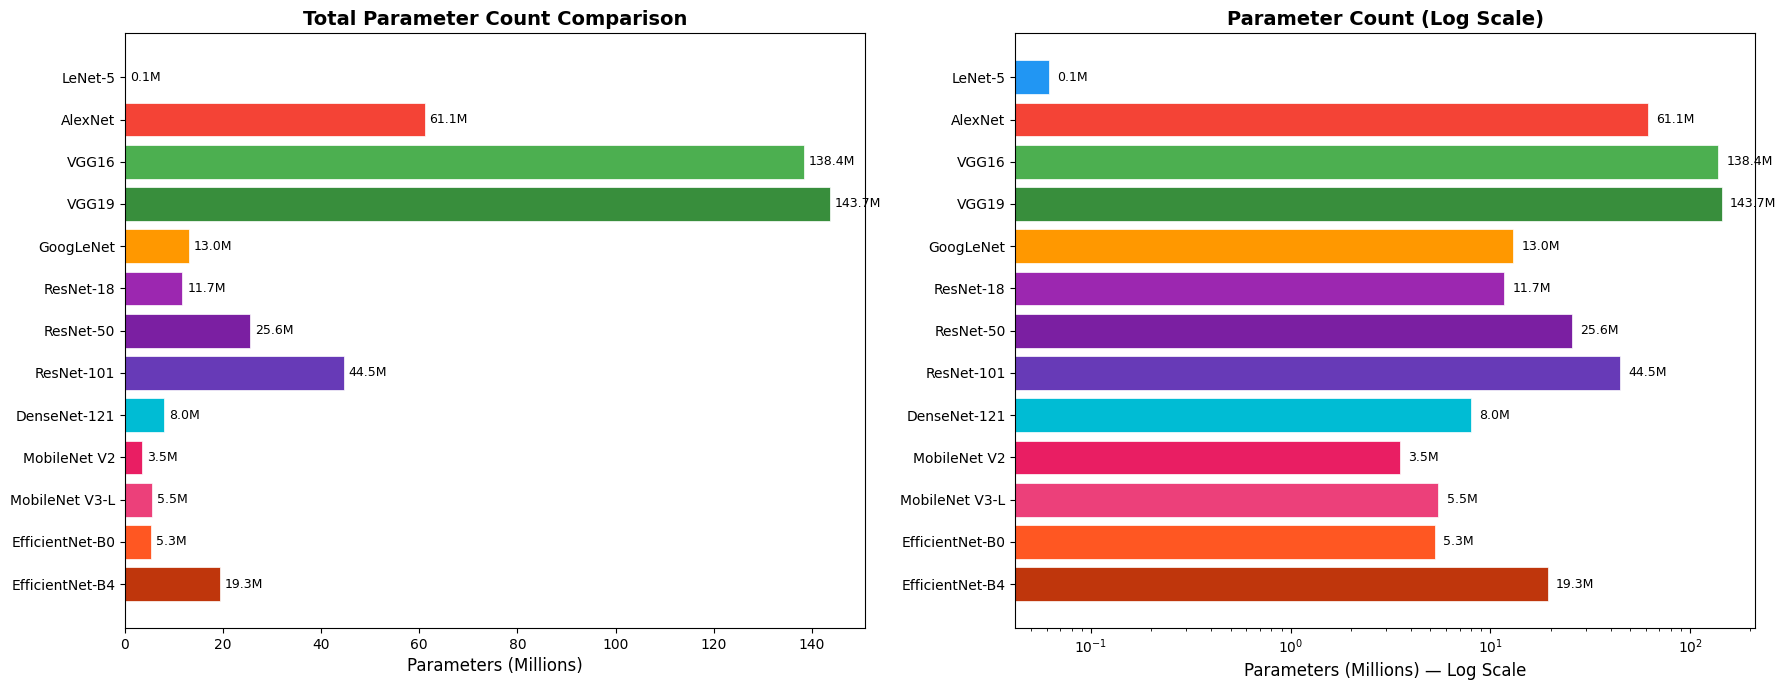

In [17]:
# ============================================================
# VISUALIZATION 1: Parameter Count Comparison (Bar Chart)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

names = list(results.keys())
params_millions = [results[n]['total'] / 1e6 for n in names]
colors = ['#2196F3', '#F44336', '#4CAF50', '#388E3C', '#FF9800',
          '#9C27B0', '#7B1FA2', '#673AB7', '#00BCD4', '#E91E63',
          '#EC407A', '#FF5722', '#BF360C']

# Bar chart
bars = axes[0].barh(names, params_millions, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Parameters (Millions)', fontsize=12)
axes[0].set_title('Total Parameter Count Comparison', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()
for bar, val in zip(bars, params_millions):
    axes[0].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}M', va='center', fontsize=9)

# Log-scale bar chart (to see small models)
bars2 = axes[1].barh(names, params_millions, color=colors, edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('Parameters (Millions) — Log Scale', fontsize=12)
axes[1].set_title('Parameter Count (Log Scale)', fontsize=14, fontweight='bold')
axes[1].set_xscale('log')
axes[1].invert_yaxis()
for bar, val in zip(bars2, params_millions):
    axes[1].text(bar.get_width() * 1.1, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}M', va='center', fontsize=9)

plt.tight_layout()
plt.show()

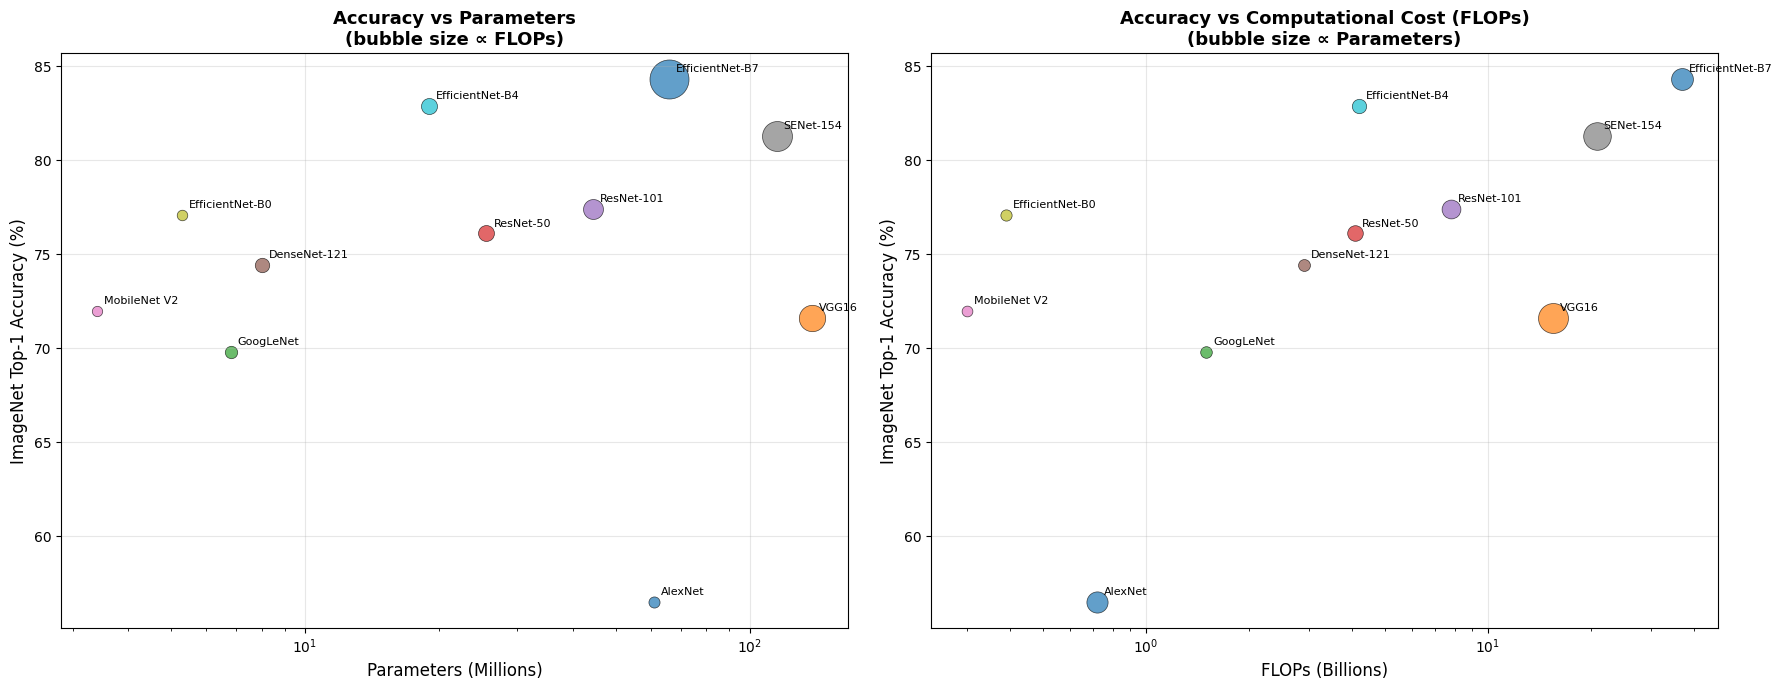

In [18]:
# ============================================================
# VISUALIZATION 2: Accuracy vs Parameters vs Year
# ============================================================

# Approximate ImageNet Top-1 accuracy data
comparison_data = {
    'LeNet-5':        {'year': 1998, 'params': 0.06,  'top1': 99.2,  'top5': 99.7,  'flops': 0.002},   # MNIST accuracy
    'AlexNet':        {'year': 2012, 'params': 61.1,  'top1': 56.5,  'top5': 84.7,  'flops': 0.72},
    'VGG16':          {'year': 2014, 'params': 138.4, 'top1': 71.6,  'top5': 92.6,  'flops': 15.5},
    'GoogLeNet':      {'year': 2014, 'params': 6.8,   'top1': 69.8,  'top5': 93.3,  'flops': 1.5},
    'ResNet-50':      {'year': 2015, 'params': 25.6,  'top1': 76.1,  'top5': 93.3,  'flops': 4.1},
    'ResNet-101':     {'year': 2015, 'params': 44.5,  'top1': 77.4,  'top5': 93.5,  'flops': 7.8},
    'DenseNet-121':   {'year': 2017, 'params': 8.0,   'top1': 74.4,  'top5': 92.0,  'flops': 2.9},
    'MobileNet V2':   {'year': 2018, 'params': 3.4,   'top1': 72.0,  'top5': 91.0,  'flops': 0.3},
    'SENet-154':      {'year': 2017, 'params': 115.1, 'top1': 81.3,  'top5': 95.5,  'flops': 20.8},
    'EfficientNet-B0':{'year': 2019, 'params': 5.3,   'top1': 77.1,  'top5': 93.3,  'flops': 0.39},
    'EfficientNet-B4':{'year': 2019, 'params': 19.0,  'top1': 82.9,  'top5': 96.4,  'flops': 4.2},
    'EfficientNet-B7':{'year': 2019, 'params': 66.0,  'top1': 84.3,  'top5': 97.0,  'flops': 37.0},
}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Top-1 Accuracy vs Parameters (bubble size = FLOPs)
names_cmp = list(comparison_data.keys())
# Exclude LeNet (MNIST accuracy not comparable)
names_cmp_imgnet = [n for n in names_cmp if n != 'LeNet-5']

for name in names_cmp_imgnet:
    d = comparison_data[name]
    axes[0].scatter(d['params'], d['top1'],
                    s=d['flops'] * 20 + 50,
                    alpha=0.7, edgecolors='black', linewidth=0.5)
    axes[0].annotate(name, (d['params'], d['top1']),
                     textcoords="offset points", xytext=(5, 5), fontsize=8)

axes[0].set_xlabel('Parameters (Millions)', fontsize=12)
axes[0].set_ylabel('ImageNet Top-1 Accuracy (%)', fontsize=12)
axes[0].set_title('Accuracy vs Parameters\n(bubble size ∝ FLOPs)', fontsize=13, fontweight='bold')
axes[0].set_xscale('log')
axes[0].grid(True, alpha=0.3)

# Plot 2: Accuracy vs FLOPs
for name in names_cmp_imgnet:
    d = comparison_data[name]
    axes[1].scatter(d['flops'], d['top1'],
                    s=d['params'] * 3 + 50,
                    alpha=0.7, edgecolors='black', linewidth=0.5)
    axes[1].annotate(name, (d['flops'], d['top1']),
                     textcoords="offset points", xytext=(5, 5), fontsize=8)

axes[1].set_xlabel('FLOPs (Billions)', fontsize=12)
axes[1].set_ylabel('ImageNet Top-1 Accuracy (%)', fontsize=12)
axes[1].set_title('Accuracy vs Computational Cost (FLOPs)\n(bubble size ∝ Parameters)', fontsize=13, fontweight='bold')
axes[1].set_xscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

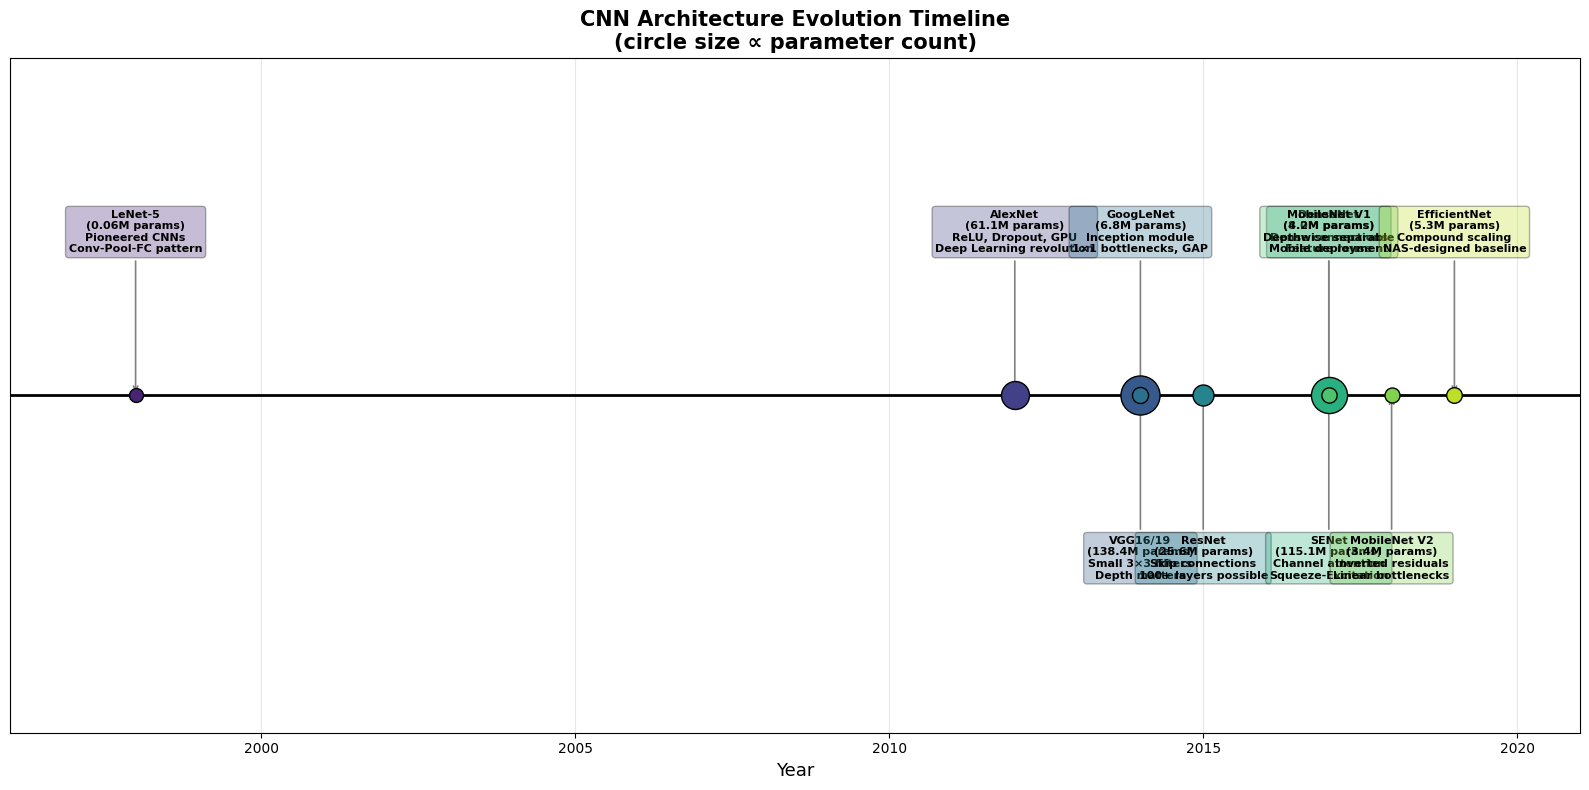

In [19]:
# ============================================================
# VISUALIZATION 3: Evolution Timeline
# ============================================================

fig, ax = plt.subplots(figsize=(16, 8))

timeline = [
    (1998, 'LeNet-5',        0.06,  'Pioneered CNNs\nConv-Pool-FC pattern'),
    (2012, 'AlexNet',        61.1,  'ReLU, Dropout, GPU\nDeep Learning revolution'),
    (2014, 'VGG16/19',       138.4, 'Small 3×3 filters\nDepth matters'),
    (2014, 'GoogLeNet',      6.8,   'Inception module\n1×1 bottlenecks, GAP'),
    (2015, 'ResNet',         25.6,  'Skip connections\n100+ layers possible'),
    (2017, 'DenseNet',       8.0,   'Dense connections\nFeature reuse'),
    (2017, 'SENet',          115.1, 'Channel attention\nSqueeze-Excitation'),
    (2017, 'MobileNet V1',   4.2,   'Depthwise separable\nMobile deployment'),
    (2018, 'MobileNet V2',   3.4,   'Inverted residuals\nLinear bottlenecks'),
    (2019, 'EfficientNet',   5.3,   'Compound scaling\nNAS-designed baseline'),
]

colors_tl = plt.cm.viridis(np.linspace(0.1, 0.9, len(timeline)))
y_positions = [0.5, 0.5, -0.5, 0.5, -0.5, 0.5, -0.5, 0.5, -0.5, 0.5]

for i, (year, name, params, desc) in enumerate(timeline):
    y = y_positions[i]
    ax.scatter(year, 0, s=params * 5 + 100, c=[colors_tl[i]], edgecolors='black',
              linewidth=1, zorder=5)
    ax.annotate(f'{name}\n({params}M params)\n{desc}',
               xy=(year, 0), xytext=(year, y),
               ha='center', va='bottom' if y > 0 else 'top',
               fontsize=8, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.3', facecolor=colors_tl[i], alpha=0.3),
               arrowprops=dict(arrowstyle='->', color='gray', lw=1.2))

ax.axhline(y=0, color='black', linewidth=2, zorder=4)
ax.set_xlim(1996, 2021)
ax.set_ylim(-1.2, 1.2)
ax.set_xlabel('Year', fontsize=13)
ax.set_title('CNN Architecture Evolution Timeline\n(circle size ∝ parameter count)',
            fontsize=15, fontweight='bold')
ax.set_yticks([])
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

---

## Summary Comparison Table

| Architecture | Year | Depth | Params | ImageNet Top-1 | Key Innovation | Best For |
|---|---|---|---|---|---|---|
| **LeNet-5** | 1998 | 5 | 60K | N/A (MNIST) | Conv-Pool-FC paradigm | Education, simple tasks |
| **AlexNet** | 2012 | 8 | 61M | 56.5% | ReLU, Dropout, GPU training | Historical importance |
| **VGG16** | 2014 | 16 | 138M | 71.6% | Uniform 3×3 filters, depth | Feature extraction, transfer learning |
| **GoogLeNet** | 2014 | 22 | 6.8M | 69.8% | Inception module, 1×1 bottleneck | Efficiency-focused tasks |
| **ResNet-50** | 2015 | 50 | 25.6M | 76.1% | Skip connections | General-purpose backbone |
| **DenseNet-121** | 2017 | 121 | 8.0M | 74.4% | Dense connections, feature reuse | Parameter-efficient tasks |
| **SENet** | 2017 | — | varies | 81.3% | Channel attention (SE block) | Attention augmentation |
| **MobileNet V2** | 2018 | — | 3.4M | 72.0% | Depthwise separable, inverted residuals | Mobile / edge deployment |
| **EfficientNet-B0** | 2019 | — | 5.3M | 77.1% | Compound scaling, NAS | Best accuracy/efficiency trade-off |
| **EfficientNet-B7** | 2019 | — | 66M | 84.3% | Scaled compound model | Maximum accuracy |

---

## Key Takeaways

1. **Depth matters** — Going deeper improves performance, but only with proper techniques (skip connections, batch norm)
2. **Skip connections are essential** — ResNet showed that identity shortcuts enable training of 100+ layer networks
3. **Efficiency innovations** — Depthwise separable convolutions (MobileNet) and compound scaling (EfficientNet) achieve great accuracy with far fewer parameters
4. **Attention helps** — Channel attention (SENet) and later spatial attention add minimal cost but meaningful accuracy gains
5. **Architecture search outperforms hand-design** — NAS-designed models (EfficientNet, MobileNetV3) consistently beat manually designed ones
6. **No single best architecture** — The choice depends on constraints:
   - **Maximum accuracy:** EfficientNet-B7, ResNet-101+
   - **Mobile deployment:** MobileNet V3, EfficientNet-B0
   - **Transfer learning backbone:** ResNet-50, VGG16
   - **Parameter efficiency:** DenseNet, GoogLeNet